# Assignment 1 - Lama Aldossary - 2230006612

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


/Users/lamadossary/.pyenv/versions/ai/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


In [3]:
# Load Dataset
df = pd.read_csv('movies.csv')
df.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1,Might toward capital,Comedy,2003,28-09-2003,China,58,7865,10596
1,2,He however experience,Comedy,1988,14-02-1988,USA,44,1708,220
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,55,4678,7805
3,4,Exactly live,Comedy,1998,06-08-1998,USA,87,2467,1751
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,67,5555,697


### Check Missing values

In [4]:
print(df.isna())

     MovieID  Title  Genre  ReleaseYear  ReleaseDate  Country  \
0      False  False  False        False        False    False   
1      False  False  False        False        False    False   
2      False  False  False        False        False    False   
3      False  False  False        False        False    False   
4      False  False  False        False        False    False   
..       ...    ...    ...          ...          ...      ...   
995    False  False  False        False        False    False   
996    False  False  False        False        False    False   
997    False  False  False        False        False    False   
998    False  False  False        False        False    False   
999    False  False  False        False        False    False   

     RottenTomatoesScore  NumVotesIMDb  NumVotesRT  
0                  False         False       False  
1                  False         False       False  
2                  False         False       False  
3      

In [16]:
print(df.isna().sum())

MovieID                10
Title                   8
Genre                   9
ReleaseYear            10
ReleaseDate            10
Country                 6
RottenTomatoesScore     5
NumVotesIMDb            8
NumVotesRT             14
dtype: int64


In [17]:
df.dropna(inplace=True)

### check duplicates

In [15]:
df.duplicated()[df.duplicated()==True]

1000    True
1001    True
1002    True
1003    True
1004    True
dtype: bool

In [18]:
df.duplicated().sum()

np.int64(5)

In [19]:
df.drop_duplicates(inplace=True)

### number of rows and columns

In [20]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (922, 9) 

number of rows:  922
number of columns:  9


### columns data type

In [ ]:
df.dtypes

MovieID                float64
Title                   object
Genre                   object
ReleaseYear            float64
ReleaseDate             object
Country                 object
RottenTomatoesScore    float64
NumVotesIMDb           float64
NumVotesRT             float64
dtype: object

In [22]:
# Convert ReleaseDate to datetime format
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce',dayfirst=True)

df.dtypes

MovieID                       float64
Title                          object
Genre                          object
ReleaseYear                   float64
ReleaseDate            datetime64[ns]
Country                        object
RottenTomatoesScore           float64
NumVotesIMDb                  float64
NumVotesRT                    float64
dtype: object

In [23]:
df.describe(include='all')

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,922.000000,922,922,922.000000,922,922,922.000000,922.000000,922.000000
unique,NaN,875,8,NaN,NaN,10,NaN,NaN,NaN
top,NaN,Course now,Drama,NaN,NaN,USA,NaN,NaN,NaN
freq,NaN,3,227,NaN,NaN,668,NaN,NaN,NaN
mean,499.050976,NaN,NaN,1997.158351,1997-08-28 19:50:06.507592192,NaN,64.706074,7888.354664,2451.150759
min,1.000000,NaN,NaN,1950.000000,1950-03-28 00:00:00,NaN,15.000000,100.000000,50.000000
25%,251.250000,NaN,NaN,1984.000000,1984-12-04 06:00:00,NaN,54.000000,1179.250000,130.250000
50%,500.500000,NaN,NaN,2000.000000,2000-03-25 00:00:00,NaN,64.000000,3000.000000,451.000000
75%,746.750000,NaN,NaN,2013.000000,2013-09-23 18:00:00,NaN,77.000000,7676.750000,1522.250000
max,1000.000000,NaN,NaN,2025.000000,2025-12-27 00:00:00,NaN,100.000000,293890.000000,175570.000000


## Descriptive summary statistics

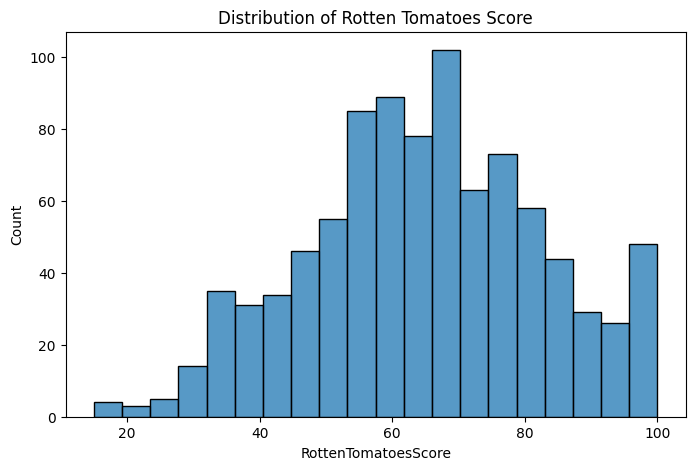

In [24]:
# Distribution of Rotten Tomatoes Score، which is a measure of the quality of the movie.
# The histogram shows that most movies have a score between 50 and 80, with a few outliers having very high or very low scores.
plt.figure(figsize=(8,5))
sns.histplot(df['RottenTomatoesScore'], bins=20)
plt.title("Distribution of Rotten Tomatoes Score")
plt.show()



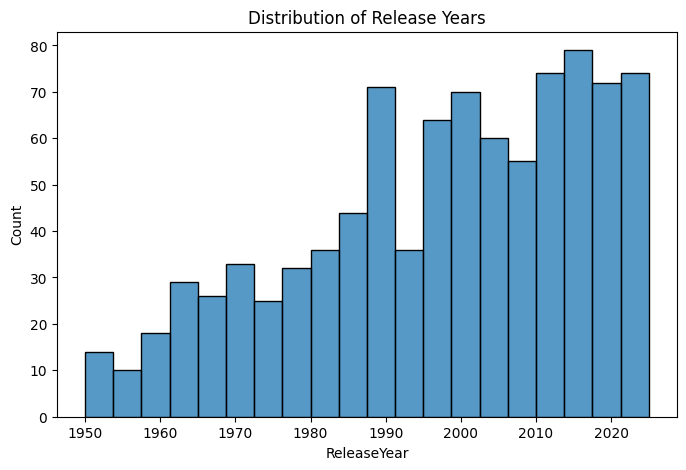

In [25]:
# Distribution of Release Years, which shows the distribution of the years in which the movies were released.
# The histogram indicates that most movies in the dataset were released between 2000 and 2020, with a peak around 2010. 
plt.figure(figsize=(8,5))
sns.histplot(df['ReleaseYear'], bins=20)
plt.title("Distribution of Release Years")
plt.show()

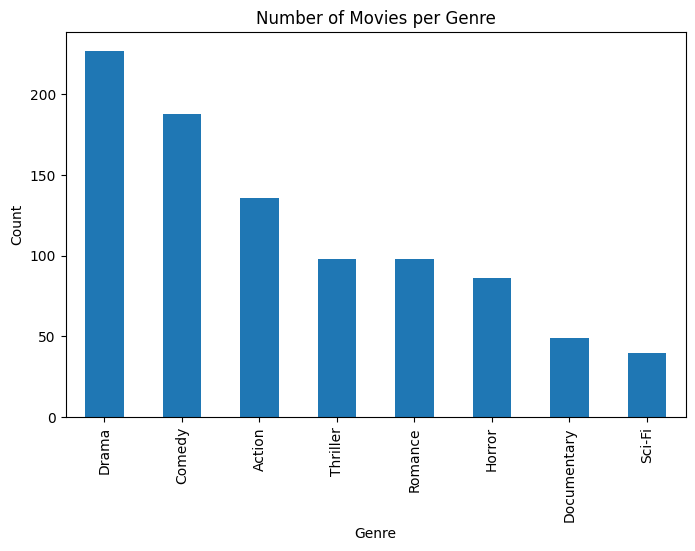

In [26]:
# Distribution of Genres, which shows the number of movies in each genre.
# The bar chart indicates that Drama is the most common genre, followed by Comedy and Action.
plt.figure(figsize=(8,5))
df['Genre'].value_counts().plot(kind='bar')
plt.title("Number of Movies per Genre")
plt.ylabel("Count")
plt.show()

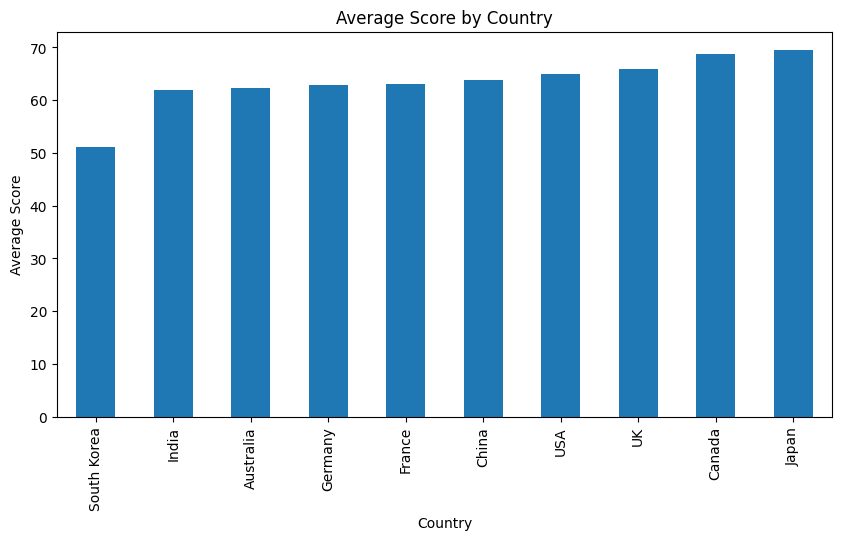

In [27]:
# Average Score by Country, which shows the average Rotten Tomatoes Score for movies from each country.
# The bar chart indicates that movies from countries like Canada and Japan tend to have higher average scores, while movies from countries like South Korea have lower average scores on Rotten Tomatoes.
country_avg = df.groupby('Country')['RottenTomatoesScore'].mean()

plt.figure(figsize=(10,5))
country_avg.sort_values().plot(kind='bar')
plt.title("Average Score by Country")
plt.ylabel("Average Score")
plt.show()

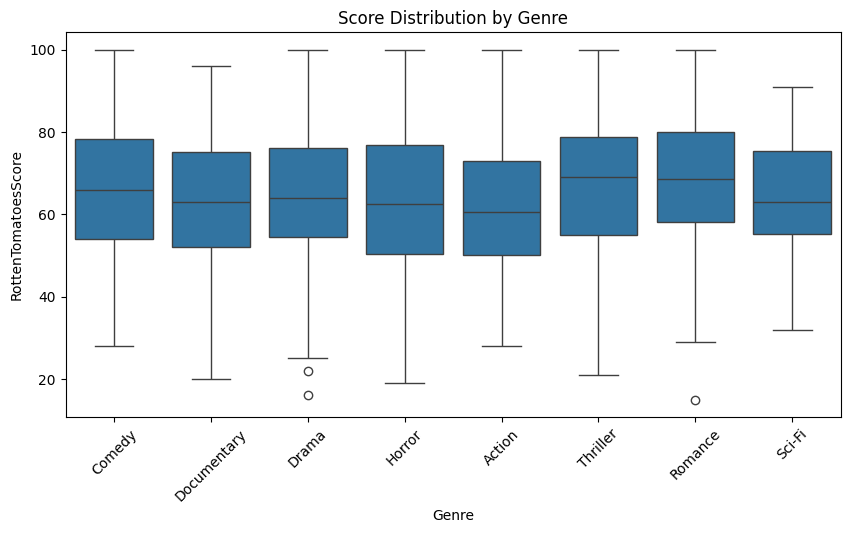

In [28]:
# Score by Genre, which shows the total Rotten Tomatoes Score for movies in each genre. 
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='RottenTomatoesScore', data=df)
plt.xticks(rotation=45)
plt.title("Score Distribution by Genre")
plt.show()



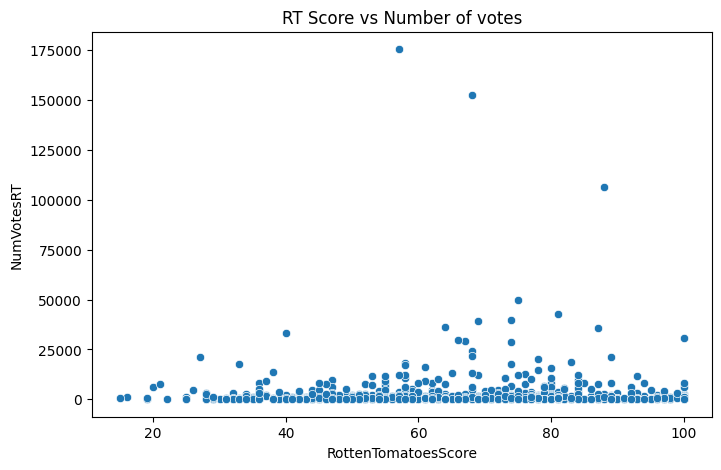

In [29]:
# RT Score vs Number of votes, which shows the relationship between the Rotten Tomatoes Score and the number of votes a movie has received on Rotten Tomatoes. 
# The scatter plot indicates that there's a positive correlation between them, meaning that movies with higher have more votes. However, there are also some outliers, such as movies with high scores but relatively few votes, and movies with low scores but many votes.
plt.figure(figsize=(8,5))
sns.scatterplot(x='RottenTomatoesScore', y='NumVotesRT', data=df)
plt.title("RT Score vs Number of votes")
plt.show()

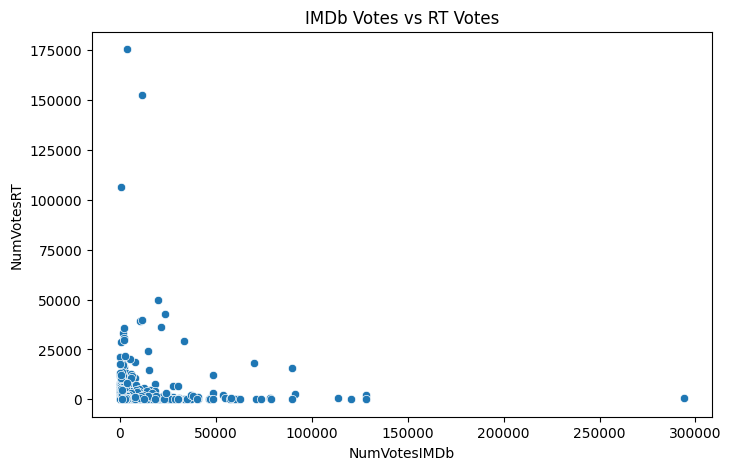

In [30]:
# IMDb Votes vs RT Votes, which shows the relationship between the number of votes a movie has received on IMDb and Rotten Tomatoes. 
# The scatter plot indicates that there's a positive correlation between them. Movies that have received a high number of votes on IMDb also tend to have received a high number of votes on Rotten Tomatoes, and vice versa. However, there are some outliers.
plt.figure(figsize=(8,5))
sns.scatterplot(x='NumVotesIMDb', y='NumVotesRT', data=df)
plt.title("IMDb Votes vs RT Votes")
plt.show()

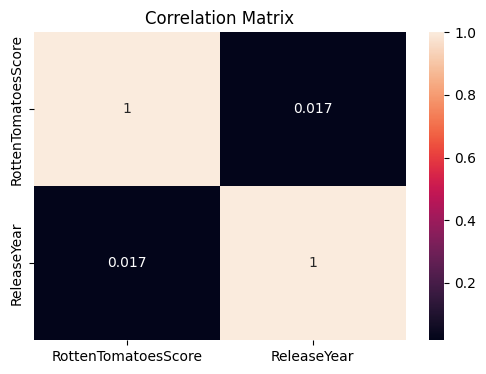

In [31]:
# Correlation Matrix, which shows the correlation between the Rotten Tomatoes Score and the Release Year of the movies. 
# The heatmap indicates that there's a weak positive correlation between them, so movies released in recent years have slightly higher Rotten Tomatoes Scores compared to older movies.
plt.figure(figsize=(6,4))
sns.heatmap(df[['RottenTomatoesScore', 'ReleaseYear']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

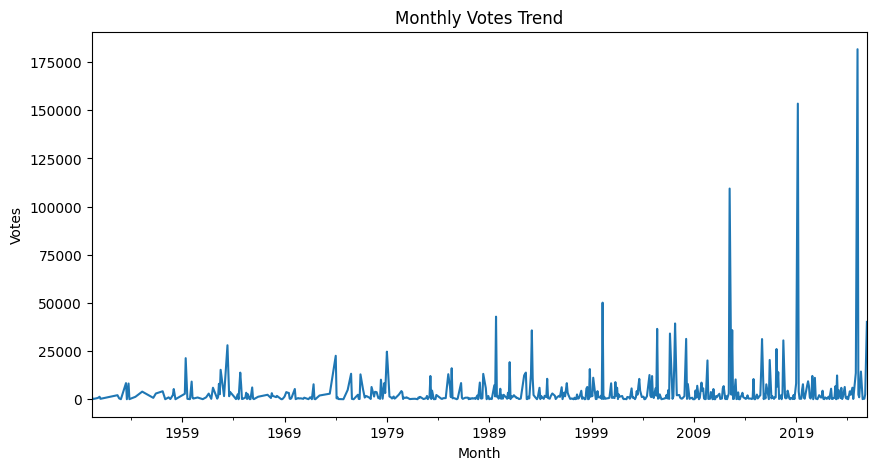

In [32]:
# Monthly Votes Trend, which shows the total number of votes on Rotten Tomatoes for movies released each month.
df['Month'] = df['ReleaseDate'].dt.to_period('M')

monthly_votes = df.groupby('Month')['NumVotesRT'].sum()

plt.figure(figsize=(10,5))
monthly_votes.plot()
plt.title("Monthly Votes Trend")
plt.ylabel("Votes")
plt.show()